# DL2 Homework 3: Transfer Learning

## Unsupervised Domain Adaptation (UDA)

*   Unsupervised Domain Adaptation assumes **access to labeled source** and **unlabeled target data**.
    * **During training**, the model uses images with labels from source data and images without labels from target data.
    *  **During evaluation**, the trained model is tested on target images, and its predictions are compared with ground truth labels.
*   The evaluation follows the standard UDA protocol.

## Setting

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
import os
import shutil

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/home/s2/hanseulkim/project/transfer/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [3]:
# ── 경로 설정 ──────────────────────────────────────────────────────────────────
PROJECT_DIR  = '/home/s2/hanseulkim/project/transfer'
CUB_200_PATH          = f'{PROJECT_DIR}/data/CUB_200_2011/images'
CUB_200_PAINTINGS_PATH = f'{PROJECT_DIR}/data/CUB_200_Paintings'
CKPT_DIR     = f'{PROJECT_DIR}/checkpoints'
OUTPUT_DIR   = PROJECT_DIR

# ── 기존 최고 weight를 사용할지, 처음부터 학습할지 ─────────────────────────────
# True  → 학습 skip, 기존 best checkpoint를 그대로 복사해서 사용
# False → 처음부터 전체 파이프라인을 학습
LOAD_EXISTING_WEIGHTS = True

# 최종 저장 경로 (evaluation 셀이 이 경로를 사용)
CtoP_CKPT_SAVE = f'{CKPT_DIR}/CtoP.pth'
PtoC_CKPT_SAVE = f'{CKPT_DIR}/PtoC.pth'

# 기존 best checkpoint 경로
CtoP_BEST_EXISTING = f'{CKPT_DIR}/CtoP_light_smooth_more.pth'   # 44.17%
PtoC_BEST_EXISTING = f'{CKPT_DIR}/PtoC_shot_only_light.pth'     # 13.23%

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Paths OK')

Paths OK


## Download Datasets

*   Caltech UCSD Birds-200 (CUB-200-2011) Datasets
*   CUB-200-Paintings Datasets

In [4]:
# 1. Download CUB200 Dataset
tgz_path   = f'{OUTPUT_DIR}/CUB_200_2011.tgz'
extract_dir = f'{OUTPUT_DIR}/data/CUB_200_2011'
url = 'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1'

if not os.path.exists(tgz_path):
    print('Downloading CUB200 Dataset...')
    os.system(f'wget -q -O "{tgz_path}" "{url}"')
else:
    print('TGZ file already exists. Skipping download.')

if not os.path.exists(extract_dir):
    print('Extracting CUB200 Dataset...')
    os.makedirs(f'{OUTPUT_DIR}/data', exist_ok=True)
    os.system(f'tar -xzf "{tgz_path}" -C "{OUTPUT_DIR}/data"')
else:
    print('Dataset already extracted. Skipping extraction.')

Dataset already extracted. Skipping extraction.


In [ ]:
# 2. Download CUB200-Paintings Dataset
zip_path    = f'{OUTPUT_DIR}/CUB_200_Paintings.zip'
extract_dir = f'{OUTPUT_DIR}/data/CUB_200_Paintings'
url = 'https://drive.google.com/uc?id=1G327KsD93eyGTjMmByuVy9sk4tlEOyK3'

if not os.path.exists(zip_path):
    print('Downloading CUB200-Paintings Dataset...')
    os.system(f'gdown "{url}" -O "{zip_path}"')
else:
    print('Zip file already exists. Skipping download.')

if not os.path.exists(extract_dir):
    print('Unzipping CUB200-Paintings Dataset...')
    os.system(f'unzip -q -o "{zip_path}" -d "{OUTPUT_DIR}/data"')
else:
    print('Dataset already extracted. Skipping unzip.')

## 1. Dataset Exploration
*   Load the CUB-200 / CUB-200 Paintings Datasets
*   Analyze the statistics and Visualize the samples

In [5]:
BATCH_SIZE = 64

cub_bird_transform = transforms.Compose([
    transforms.Resize(224), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

cub_bird_paintings_transform = transforms.Compose([
    transforms.Resize(224), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.7815, 0.7699, 0.7322), (0.2654, 0.2694, 0.2941))
])

cub_dataset = ImageFolder(root=CUB_200_PATH, transform=cub_bird_transform)
cub_paintings_dataset = ImageFolder(root=CUB_200_PAINTINGS_PATH, transform=cub_bird_paintings_transform)

cub_loader = DataLoader(cub_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
cub_paintings_loader = DataLoader(cub_paintings_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [6]:
print('==================================================')
print(f'SOURCE DATA SIZE : {len(cub_dataset)} / TARGET DATA SIZE : {len(cub_paintings_dataset)}')
print(f'SAME LABEL SPACE? : {set(cub_dataset.targets) == set(cub_paintings_dataset.targets)}')
print(f'# of categories : {len(set(cub_dataset.targets))}')
print('==================================================')

SOURCE DATA SIZE : 11788 / TARGET DATA SIZE : 3047
SAME LABEL SPACE? : True
# of categories : 200


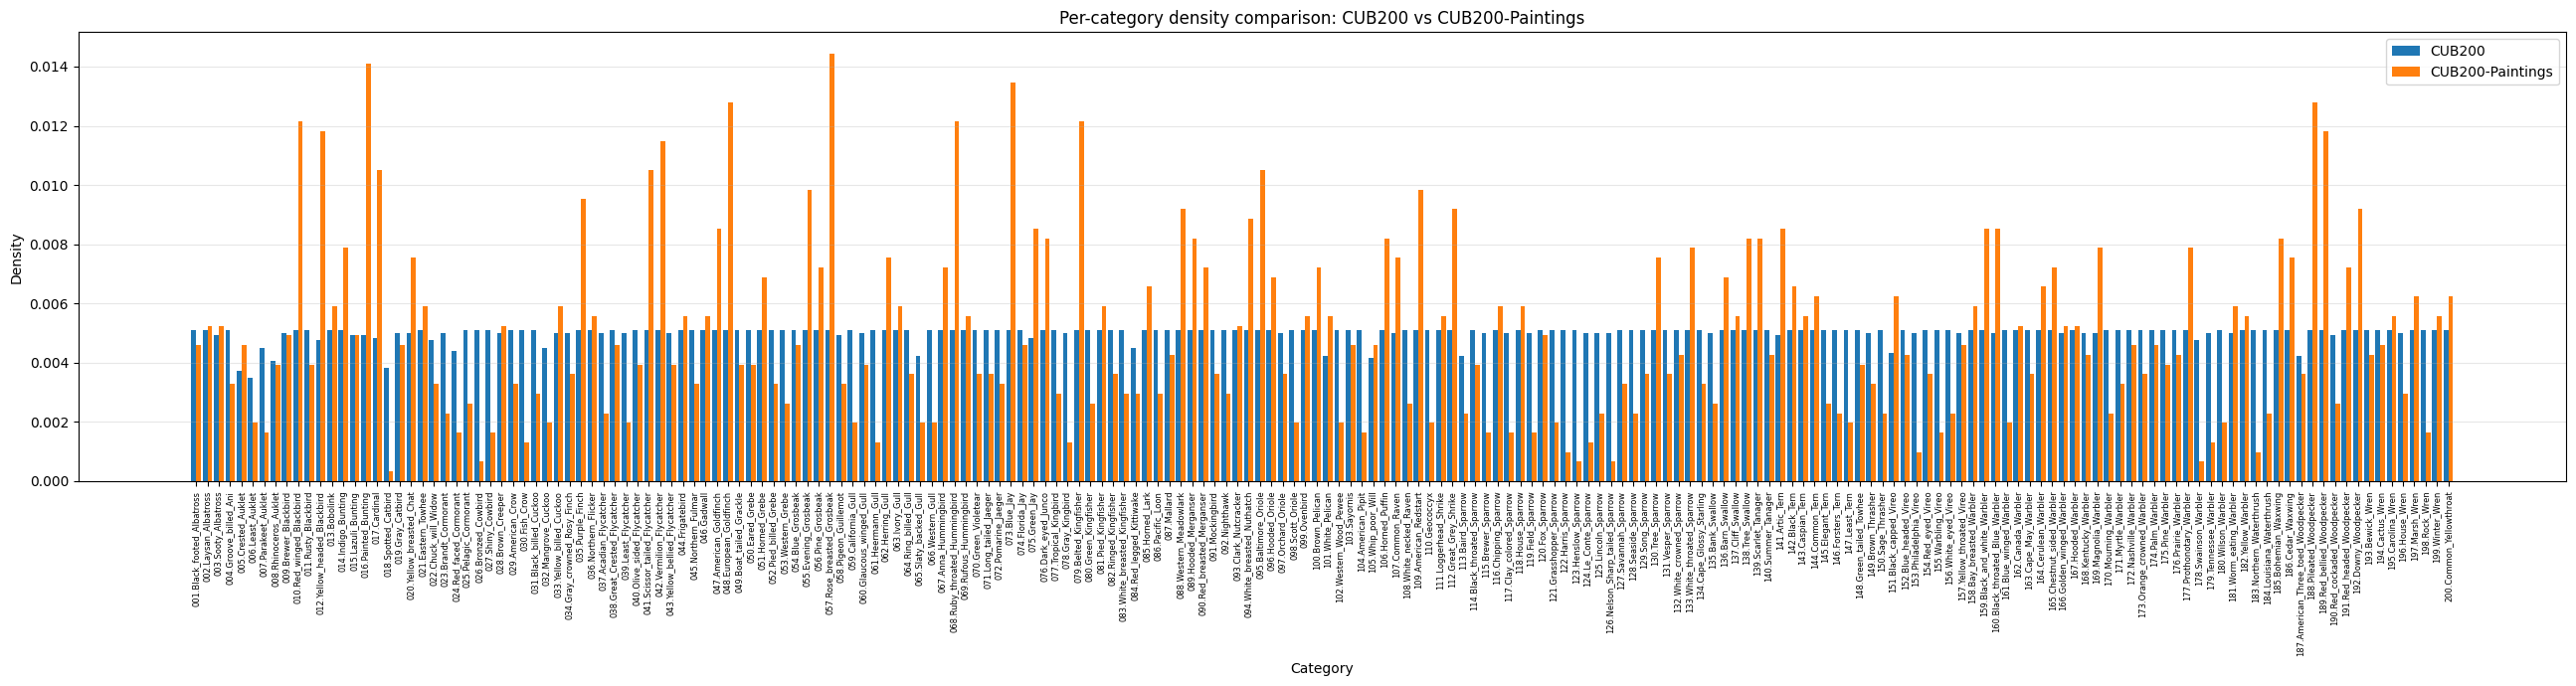

In [7]:
def get_class_counts(dataset, name):
    label_counts = Counter(dataset.targets)
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    return pd.DataFrame([{'label_idx': idx, 'class_name': cls, name: label_counts.get(idx, 0)}
                          for idx, cls in idx_to_class.items()])

cub_df   = get_class_counts(cub_dataset, 'cub_count')
paint_df = get_class_counts(cub_paintings_dataset, 'paint_count')
df = cub_df.merge(paint_df, on=['label_idx', 'class_name'], how='outer').fillna(0)
df['cub_density']   = df['cub_count']   / df['cub_count'].sum()
df['paint_density'] = df['paint_count'] / df['paint_count'].sum()
df = df.sort_values('label_idx').reset_index(drop=True)

plt.figure(figsize=(26, 7))
x, width = range(len(df)), 0.42
plt.bar([i - width/2 for i in x], df['cub_density'],   width=width, label='CUB200')
plt.bar([i + width/2 for i in x], df['paint_density'], width=width, label='CUB200-Paintings')
plt.xlabel('Category'); plt.ylabel('Density')
plt.title('Per-category density comparison: CUB200 vs CUB200-Paintings')
plt.xticks(ticks=list(x), labels=df['class_name'], rotation=90, fontsize=6)
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

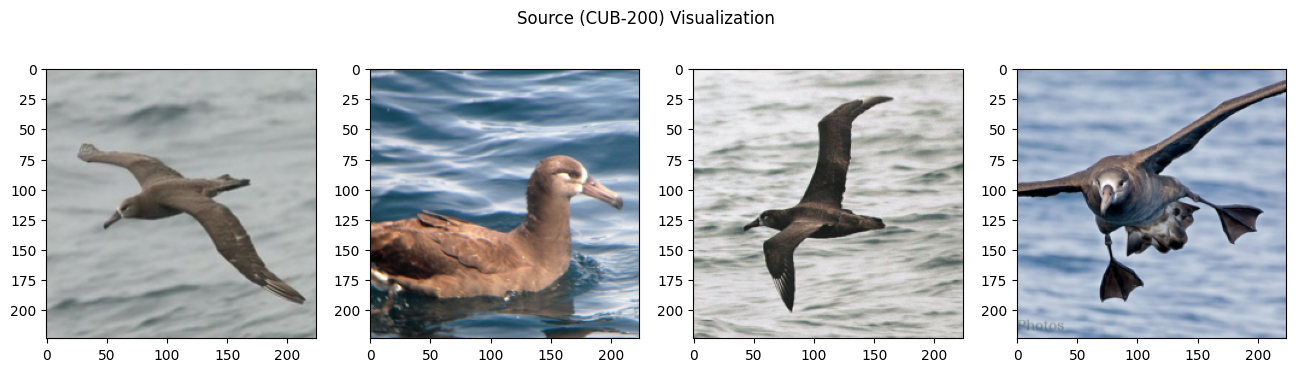

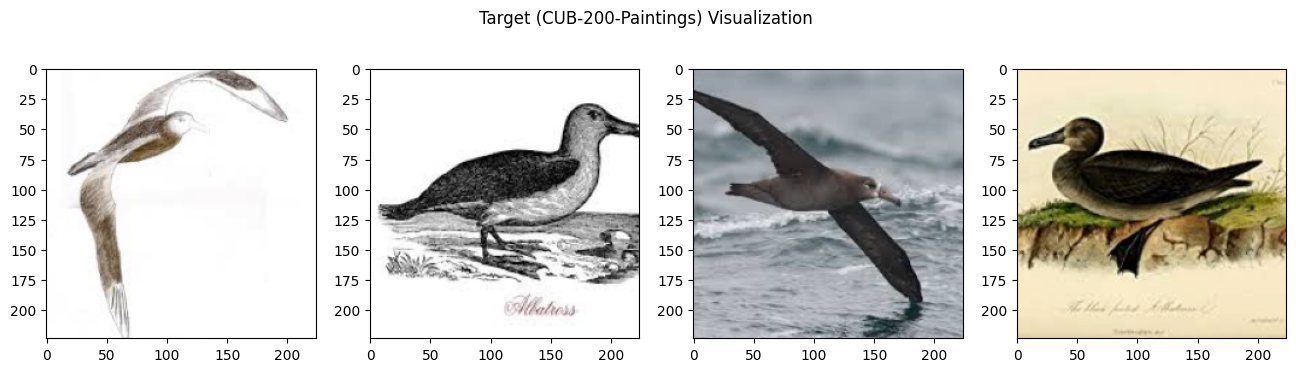

In [8]:
to_pil = transforms.functional.to_pil_image
cub_denorm = transforms.Normalize(
    mean=[-m/s for m,s in zip((0.485,0.456,0.406),(0.229,0.224,0.225))],
    std=[1/s for s in (0.229,0.224,0.225)])

images, _ = next(iter(cub_loader))
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4): ax[i].imshow(to_pil(cub_denorm(images[i]).clamp(0,1)))
plt.suptitle('Source (CUB-200) Visualization'); plt.show()

paint_denorm = transforms.Normalize(
    mean=[-m/s for m,s in zip((0.7815,0.7699,0.7322),(0.2654,0.2694,0.2941))],
    std=[1/s for s in (0.2654,0.2694,0.2941)])

images, _ = next(iter(cub_paintings_loader))
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4): ax[i].imshow(to_pil(paint_denorm(images[i]).clamp(0,1)))
plt.suptitle('Target (CUB-200-Paintings) Visualization'); plt.show()

## 2. Define the Model Architecture

ResNetUDA: ResNet-18 scale with GroupNorm, SE blocks, projector head + classifier head (11.7M params). **No pretrained weights used.**

In [9]:
class SEBlock(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()
        mid = max(channels // r, 4)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, mid), nn.ReLU(),
            nn.Linear(mid, channels), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.se(x).view(x.size(0), -1, 1, 1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, groups=32):
        super().__init__()
        g = lambda c: min(groups, c)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.norm1 = nn.GroupNorm(g(out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.norm2 = nn.GroupNorm(g(out_ch), out_ch)
        self.se    = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.GroupNorm(g(out_ch), out_ch),
            )
    def forward(self, x):
        out = F.relu(self.norm1(self.conv1(x)))
        out = self.se(self.norm2(self.conv2(out)))
        return F.relu(out + self.shortcut(x))


class ResNetUDA(nn.Module):
    """ResNet-18-scale with GroupNorm + SE blocks. No pretrained weights."""
    def __init__(self, num_classes=200, proj_dim=128, groups=32):
        super().__init__()
        g = lambda c: min(groups, c)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.GroupNorm(g(64), 64), nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(64,  64,  2, stride=1, groups=groups)
        self.layer2 = self._make_layer(64,  128, 2, stride=2, groups=groups)
        self.layer3 = self._make_layer(128, 256, 2, stride=2, groups=groups)
        self.layer4 = self._make_layer(256, 512, 2, stride=2, groups=groups)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.projector  = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, proj_dim))
        self.classifier = nn.Linear(512, num_classes)

    @staticmethod
    def _make_layer(in_ch, out_ch, n, stride, groups):
        return nn.Sequential(
            ResBlock(in_ch, out_ch, stride=stride, groups=groups),
            *[ResBlock(out_ch, out_ch, groups=groups) for _ in range(1, n)],
        )

    def encode(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.pool(x).flatten(1)

    def forward(self, x):
        return self.classifier(self.encode(x))


model = ResNetUDA(num_classes=200, proj_dim=128).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResNetUDA  params: {n_params/1e6:.2f}M')
print(model)

ResNetUDA  params: 11.70M
ResNetUDA(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): GroupNorm(32, 64, eps=1e-05, affine=True, bias=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm1): GroupNorm(32, 64, eps=1e-05, affine=True, bias=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): GroupNorm(32, 64, eps=1e-05, affine=True, bias=True)
      (se): SEBlock(
        (se): Sequential(
          (0): AdaptiveAvgPool2d(output_size=1)
          (1): Flatten(start_dim=1, end_dim=-1)
          (2): Linear(in_features=64, out_features=4, bias=True)
          (3): ReLU()
          (4): Linear(in_features=4, out_features=64, bias=True)
          (5): Sigmoid()
    

## 3. Set the training environments

*   **[Setting1]** C→P : Use CUB-200 as Source, CUB-200-Paintings as Target.  Best method: **joint pseudo-label + SHOT** (44.17%)
*   **[Setting2]** P→C : Use CUB-200-Paintings as Source, CUB-200 as Target. Best method: **source training + SHOT** (13.23%)

In [ ]:
# ── Transforms ────────────────────────────────────────────────────────────────
CUB_MEAN, CUB_STD     = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
PAINT_MEAN, PAINT_STD = (0.7815, 0.7699, 0.7322), (0.2654, 0.2694, 0.2941)

def get_transform(domain, augment=False):
    mean, std = (CUB_MEAN, CUB_STD) if domain == 'cub' else (PAINT_MEAN, PAINT_STD)
    if augment:
        return transforms.Compose([
            transforms.Resize(224), transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            transforms.RandomRotation(15),
            transforms.ToTensor(), transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize(224), transforms.CenterCrop(224),
        transforms.ToTensor(), transforms.Normalize(mean, std),
    ])


# ── Datasets ──────────────────────────────────────────────────────────────────
class UnlabeledDataset(Dataset):
    def __init__(self, labeled_dataset):
        self.dataset = labeled_dataset
    def __len__(self):  return len(self.dataset)
    def __getitem__(self, idx):
        img, _ = self.dataset[idx]; return img


class PseudoLabeledDataset(Dataset):
    def __init__(self, root, transform, indices, pseudo_labels):
        self.base = ImageFolder(root=root, transform=transform)
        self.indices = indices; self.pseudo_labels = pseudo_labels
    def __len__(self):  return len(self.indices)
    def __getitem__(self, i):
        img, _ = self.base[self.indices[i]]
        return img, self.pseudo_labels[i]


class PseudoTargetDataset(Dataset):
    def __init__(self, root, transform, pseudo_labels):
        self.base = ImageFolder(root=root, transform=transform)
        self.pseudo_labels = pseudo_labels
    def __len__(self):  return len(self.base)
    def __getitem__(self, idx):
        img, true_lbl = self.base[idx]
        return img, int(self.pseudo_labels[idx]), true_lbl


# ── Evaluation ────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for imgs, labels in loader:
        pred = model(imgs.to(device)).argmax(1).cpu()
        correct += (pred == labels).sum().item()
        total   += labels.size(0)
    return 100 * correct / total


# ── Pseudo-label generation (threshold-based) ─────────────────────────────────
@torch.no_grad()
def generate_pseudo_labels(model, tgt_root, tgt_tf, device, threshold=0.7, batch_size=64):
    model.eval()
    ds = ImageFolder(root=tgt_root, transform=tgt_tf)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4)
    all_probs = []
    for imgs, _ in loader:
        feat  = model.encode(imgs.to(device))
        probs = F.softmax(model.classifier(feat), dim=1)
        all_probs.append(probs.cpu())
    all_probs = torch.cat(all_probs)
    max_probs, pseudo_labels = all_probs.max(1)
    mask = max_probs >= threshold
    indices = torch.where(mask)[0].tolist()
    labels  = pseudo_labels[mask].tolist()
    return indices, labels


# ── SHOT helpers ──────────────────────────────────────────────────────────────
def im_loss(logits):
    probs  = F.softmax(logits, dim=1)
    L_ent  = -(probs * (probs + 1e-8).log()).sum(1).mean()
    mean_p = probs.mean(0)
    L_div  = (mean_p * (mean_p + 1e-8).log()).sum()
    return L_ent + L_div


@torch.no_grad()
def compute_shot_pseudo_labels(model, loader, device, num_classes=200):
    model.eval()
    feats, probs = [], []
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        f = model.encode(imgs.to(device))
        p = F.softmax(model.classifier(f), dim=1)
        feats.append(f.cpu()); probs.append(p.cpu())
    feats = torch.cat(feats); probs = torch.cat(probs)
    feats_n = F.normalize(feats, dim=1)
    protos  = torch.zeros(num_classes, feats.shape[1])
    for c in range(num_classes):
        w = probs[:, c]
        protos[c] = (w.unsqueeze(1) * feats_n).sum(0) / (w.sum() + 1e-8)
    protos = F.normalize(protos, dim=1)
    return (feats_n @ protos.T).argmax(dim=1)


def shot_epoch(model, loader, optimizer, device):
    model.train()
    total = n = 0
    for imgs, pseudo_lbls, _ in tqdm(loader, desc='[SHOT]', leave=False):
        imgs, pseudo_lbls = imgs.to(device), pseudo_lbls.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = im_loss(logits) + F.cross_entropy(logits, pseudo_lbls)
        loss.backward()
        optimizer.step()
        total += loss.item(); n += 1
    return total / n


def run_shot(model, tgt_root, tgt_tf, eval_loader, device,
             shot_lr=1e-4, shot_rounds=3, shot_epochs=15,
             best_saver=None):
    for p in model.classifier.parameters():
        p.requires_grad_(False)
    opt = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=shot_lr, momentum=0.9, weight_decay=5e-4)
    feat_ds  = UnlabeledDataset(ImageFolder(root=tgt_root, transform=tgt_tf))
    feat_ldr = DataLoader(feat_ds, batch_size=64, shuffle=False, num_workers=4)
    true_labels = torch.tensor(feat_ds.dataset.targets)
    best = 0.0
    for rnd in range(1, shot_rounds + 1):
        pseudo = compute_shot_pseudo_labels(model, feat_ldr, device)
        pl_acc = (pseudo == true_labels).float().mean().item() * 100
        pseudo_ds  = PseudoTargetDataset(tgt_root, tgt_tf, pseudo)
        pseudo_ldr = DataLoader(pseudo_ds, batch_size=64, shuffle=True, num_workers=4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=shot_epochs)
        for ep in range(shot_epochs):
            shot_epoch(model, pseudo_ldr, opt, device)
            tgt_acc = evaluate(model, eval_loader, device)
            best = max(best, tgt_acc)
            if best_saver and tgt_acc > best_saver.best:
                best_saver.best = tgt_acc
                torch.save(model.state_dict(), best_saver.path)
            sched.step()
            print(f'  SHOT R{rnd} ep{ep+1}/{shot_epochs}  pl_acc={pl_acc:.1f}%  tgt={tgt_acc:.2f}%')
    for p in model.classifier.parameters():
        p.requires_grad_(True)
    return best


class BestSaver:
    def __init__(self, path): self.path = path; self.best = 0.0
    def update(self, model, acc):
        if acc > self.best:
            self.best = acc
            torch.save(model.state_dict(), self.path)


print('Helper functions defined.')

## 4. Train the Network

**[Setting1] CtoP** — Joint pseudo-label training + SHOT (best: **44.17%**)  
**[Setting2] PtoC** — Source-only training + SHOT (best: **13.23%**)

**[IMPORTANT]** Target labels are NOT used during training.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# [Setting1] C→P Training  (light_smooth_more: 44.17%)
# ═══════════════════════════════════════════════════════════════════════════════
set_seed(42)
model = ResNetUDA(num_classes=200, proj_dim=128).to(device)
saver_ctop = BestSaver(CtoP_CKPT_SAVE)

if LOAD_EXISTING_WEIGHTS:
    print(f'Loading existing CtoP best weights: {CtoP_BEST_EXISTING}')
    model.load_state_dict(torch.load(CtoP_BEST_EXISTING, map_location=device))
    saver_ctop.best = 44.17  # known best from experiment
    torch.save(model.state_dict(), CtoP_CKPT_SAVE)
    print(f'Copied to {CtoP_CKPT_SAVE}')
else:
    # ── Phase 1: Warmup (CE + noise NCE, 30 epochs) ───────────────────────────
    WARMUP     = 30
    ROUNDS     = 7
    ROUND_EPS  = 10
    THRESHOLD  = 0.7
    LAMBDA_NCE = 0.05
    SMOOTH     = 0.05

    src_tf  = get_transform('cub',      augment=True)
    tgt_tf  = get_transform('paintings', augment=False)
    src_ds  = ImageFolder(root=CUB_200_PATH, transform=src_tf)
    tgt_unl = UnlabeledDataset(ImageFolder(root=CUB_200_PAINTINGS_PATH, transform=tgt_tf))
    src_ldr = DataLoader(src_ds,  batch_size=64, shuffle=True,  num_workers=4)
    tgt_ldr = DataLoader(tgt_unl, batch_size=64, shuffle=True,  num_workers=4)

    src_eval_ds  = ImageFolder(root=CUB_200_PATH, transform=get_transform('cub'))
    eval_ds      = ImageFolder(root=CUB_200_PAINTINGS_PATH, transform=tgt_tf)
    src_eval_ldr = DataLoader(src_eval_ds, batch_size=64, shuffle=False, num_workers=4)
    eval_ldr     = DataLoader(eval_ds,     batch_size=64, shuffle=False, num_workers=4)

    criterion = nn.CrossEntropyLoss(label_smoothing=SMOOTH)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP)

    print('=== Phase 1: Warmup ===')
    for ep in range(WARMUP):
        model.train()
        ce_sum = nce_sum = n = 0
        tgt_iter = iter(tgt_ldr)
        for src_imgs, src_lbls in tqdm(src_ldr, desc=f'Warmup {ep+1}', leave=False):
            try: tgt_imgs = next(tgt_iter)
            except StopIteration: tgt_iter = iter(tgt_ldr); tgt_imgs = next(tgt_iter)
            src_imgs, src_lbls = src_imgs.to(device), src_lbls.to(device)
            tgt_imgs = tgt_imgs.to(device)
            optimizer.zero_grad()
            feat_src = model.encode(src_imgs)
            ce  = criterion(model.classifier(feat_src), src_lbls)
            # noise-based InfoNCE on target
            feat_tgt  = model.encode(tgt_imgs)
            feat_tgt2 = model.encode(tgt_imgs + torch.randn_like(tgt_imgs) * 0.05)
            q = F.normalize(model.projector(feat_tgt),  dim=1)
            k = F.normalize(model.projector(feat_tgt2), dim=1)
            logits_nce = q @ k.T / 0.1
            nce = F.cross_entropy(logits_nce, torch.arange(q.size(0), device=device))
            loss = ce + LAMBDA_NCE * nce
            loss.backward(); optimizer.step()
            ce_sum += ce.item(); nce_sum += nce.item(); n += 1
        scheduler.step()
        tgt_acc = evaluate(model, eval_ldr, device)
        saver_ctop.update(model, tgt_acc)
        print(f'  Warmup {ep+1}/{WARMUP}  CE={ce_sum/n:.4f}  NCE={nce_sum/n:.4f}  tgt={tgt_acc:.2f}%')

    # ── Phase 1: Pseudo rounds ─────────────────────────────────────────────────
    print('\n=== Phase 1: Pseudo Rounds ===')
    src_ds_clean = ImageFolder(root=CUB_200_PATH, transform=src_tf)  # same augmented source
    for rnd in range(1, ROUNDS + 1):
        indices, pseudo_labels = generate_pseudo_labels(
            model, CUB_200_PAINTINGS_PATH, tgt_tf, device, threshold=THRESHOLD)
        print(f'  [Round {rnd}/{ROUNDS}]  pseudo={len(indices)} ({100*len(indices)/len(eval_ds):.1f}%)')
        if len(indices) == 0: print('  No pseudo-labels — skip.'); continue
        pseudo_ds  = PseudoLabeledDataset(CUB_200_PAINTINGS_PATH, tgt_tf, indices, pseudo_labels)
        combined   = ConcatDataset([src_ds_clean, pseudo_ds])
        combined_ldr = DataLoader(combined, batch_size=64, shuffle=True, num_workers=4)
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ROUND_EPS)
        tgt_iter = iter(tgt_ldr)
        for ep in range(ROUND_EPS):
            model.train()
            ce_sum = n = 0
            for batch in tqdm(combined_ldr, desc=f'R{rnd} ep{ep+1}', leave=False):
                if len(batch[1].shape) == 0: continue
                imgs, lbls = batch[0].to(device), batch[1].to(device)
                optimizer.zero_grad()
                loss = criterion(model(imgs), lbls)
                loss.backward(); optimizer.step()
                ce_sum += loss.item(); n += 1
            scheduler.step()
            tgt_acc = evaluate(model, eval_ldr, device)
            saver_ctop.update(model, tgt_acc)
            print(f'  R{rnd} ep{ep+1}/{ROUND_EPS}  CE={ce_sum/n:.4f}  tgt={tgt_acc:.2f}%')

    # ── Phase 2: SHOT ──────────────────────────────────────────────────────────
    print('\n=== Phase 2: SHOT ===')
    run_shot(model, CUB_200_PAINTINGS_PATH, tgt_tf, eval_ldr, device,
             shot_lr=5e-4, shot_rounds=5, shot_epochs=20, best_saver=saver_ctop)

    print(f'\nCtoP best_tgt={saver_ctop.best:.2f}%  saved → {CtoP_CKPT_SAVE}')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# [Setting2] P→C Training  (shot_only_light: 13.23%)
# ═══════════════════════════════════════════════════════════════════════════════
set_seed(42)
model = ResNetUDA(num_classes=200, proj_dim=128).to(device)
saver_ptoc = BestSaver(PtoC_CKPT_SAVE)

if LOAD_EXISTING_WEIGHTS:
    print(f'Loading existing PtoC best weights: {PtoC_BEST_EXISTING}')
    model.load_state_dict(torch.load(PtoC_BEST_EXISTING, map_location=device))
    saver_ptoc.best = 13.23
    torch.save(model.state_dict(), PtoC_CKPT_SAVE)
    print(f'Copied to {PtoC_CKPT_SAVE}')
else:
    SRC_EPOCHS = 80
    src_tf  = get_transform('paintings', augment=True)
    tgt_tf  = get_transform('cub',       augment=False)
    src_ds  = ImageFolder(root=CUB_200_PAINTINGS_PATH, transform=src_tf)
    src_ldr = DataLoader(src_ds, batch_size=64, shuffle=True,  num_workers=4)

    src_eval_ds  = ImageFolder(root=CUB_200_PAINTINGS_PATH, transform=get_transform('paintings'))
    eval_ds      = ImageFolder(root=CUB_200_PATH, transform=tgt_tf)
    src_eval_ldr = DataLoader(src_eval_ds, batch_size=64, shuffle=False, num_workers=4)
    eval_ldr     = DataLoader(eval_ds,     batch_size=64, shuffle=False, num_workers=4)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SRC_EPOCHS)

    # ── Phase 1: Source training ───────────────────────────────────────────────
    print('=== Phase 1: Source Training ===')
    for ep in range(SRC_EPOCHS):
        model.train()
        loss_sum = n = 0
        for imgs, lbls in tqdm(src_ldr, desc=f'Source {ep+1}', leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward(); optimizer.step()
            loss_sum += loss.item(); n += 1
        scheduler.step()
        src_acc = evaluate(model, src_eval_ldr, device)
        print(f'  Source {ep+1}/{SRC_EPOCHS}  loss={loss_sum/n:.4f}  src_eval={src_acc:.2f}%')

    # ── Phase 2: SHOT ──────────────────────────────────────────────────────────
    print('\n=== Phase 2: SHOT ===')
    run_shot(model, CUB_200_PATH, tgt_tf, eval_ldr, device,
             shot_lr=1e-4, shot_rounds=3, shot_epochs=15, best_saver=saver_ptoc)

    print(f'\nPtoC best_tgt={saver_ptoc.best:.2f}%  saved → {PtoC_CKPT_SAVE}')

## 5. Evaluation and Submit

*   **[Setting1]** C→P : Evaluate on CUB-200-Paintings.
*   **[Setting2]** P→C : Evaluate on CUB-200.

Do not change the code cells below.

In [10]:
# ── Evaluation: best checkpoints 직접 로드 ──────────────────────────────────
# CtoP best: light_smooth_more (44.17%)  PtoC best: shot_only_light (13.23%)
CtoP_CKPT_PATH = f'{CKPT_DIR}/CtoP_light_smooth_more.pth'
PtoC_CKPT_PATH = f'{CKPT_DIR}/PtoC_shot_only_light.pth'
BATCH_SIZE = 64

# eval 셀이 model 변수를 필요로 하므로 여기서 초기화
model = ResNetUDA(num_classes=200, proj_dim=128).to(device)

import os
assert os.path.exists(CtoP_CKPT_PATH), f'CtoP checkpoint not found: {CtoP_CKPT_PATH}'
assert os.path.exists(PtoC_CKPT_PATH), f'PtoC checkpoint not found: {PtoC_CKPT_PATH}'
print(f'CtoP ckpt : {CtoP_CKPT_PATH}')
print(f'PtoC ckpt : {PtoC_CKPT_PATH}')
print('Ready for evaluation.')


CtoP ckpt : /home/s2/hanseulkim/project/transfer/checkpoints/CtoP_light_smooth_more.pth
PtoC ckpt : /home/s2/hanseulkim/project/transfer/checkpoints/PtoC_shot_only_light.pth
Ready for evaluation.


In [11]:
# 1. [Evaluation: Setting1] Source: CUB-200, Target: CUB-200-Paintings
# ======================== DO NOT CHANGE THE CODE CELL BELOW ======================== #
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Load saved checkpoints
model.load_state_dict(torch.load(CtoP_CKPT_PATH))


cub_bird_paintings_transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize((0.7815, 0.7699, 0.7322), (0.2654, 0.2694, 0.2941))
    ])

cub_paintings_dataset = ImageFolder(root=CUB_200_PAINTINGS_PATH, transform = cub_bird_paintings_transform)
val_dataset = cub_paintings_dataset
val_data_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle=False, num_workers = 4)
# ====================================================================================== #

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [ ]:
# ======================== DO NOT CHANGE THE CODE CELL BELOW ======================== #
val_dataset = cub_paintings_dataset
correct = 0
total = 0

predictions_list = []

with torch.no_grad():
    for i, data in enumerate(tqdm(val_data_loader)):
        images, labels = data
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted.cpu() == labels).sum().item()
        predictions_list.extend(predicted.cpu().numpy()) # Store predictions

# Save predictions to a .npy file
predictions_array = np.array(predictions_list)
np.save(f"{OUTPUT_DIR}/predictions_CtoP.npy", predictions_array)

print(f'[Evaluation1] Accuracy of the network on the CUB-200-Paintings: {100 * correct / total:.2f} %')
# ====================================================================================== #

In [ ]:
# 2. [Evaluation: Setting2] Source: CUB-200-Paintings, Target: CUB-200
# ======================== DO NOT CHANGE THE CODE CELL BELOW ======================== #

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Load saved checkpoints
model.load_state_dict(torch.load(PtoC_CKPT_PATH))


cub_bird_transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])


cub_dataset = ImageFolder(root=CUB_200_PATH, transform = cub_bird_transform)
val_dataset = cub_dataset
val_data_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle=False, num_workers = 4)
# ====================================================================================== #

In [ ]:
# ======================== DO NOT CHANGE THE CODE CELL BELOW ======================== #

correct = 0
total = 0

predictions_list = [] # Initialize a list to store predictions

with torch.no_grad():
    for i, data in enumerate(tqdm(val_data_loader)):
        images, labels = data
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted.cpu() == labels).sum().item()
        predictions_list.extend(predicted.cpu().numpy()) # Store predictions

# Save predictions to a .npy file
predictions_array = np.array(predictions_list)
np.save(f"{OUTPUT_DIR}/predictions_PtoC.npy", predictions_array)

print(f'[Evaluation2] Accuracy of the network on the CUB-200: {100 * correct / total:.2f} %')
# ====================================================================================== #

## **[Checklist]**

✅ Confirm that the same architecture was used for both settings.

✅ Confirm that target labels were not used during training.

✅ Confirm that the report is within 2 pages.  
   The font size must be at least 11 pt, and the line spacing must be at least 1.15.

✅ Confirm that your code is saved as `StudentID_Name.ipynb` or `StudentID_Name.py`.

After completing the checklist above, submit a `.zip` file to **ETL > DL_HW3 Assignment Submission**. The zip file must include following:
- `StudentID_Name.pdf`: the report in PDF format
- `StudentID_Name.ipynb` or `StudentID_Name.py`: your source code
- `predictions_CtoP.npy` and `predictions_PtoC.npy`: your prediction files